# Interpretable Sentiment Classification in SE Communication

**CSE 4122** * Al Shariar Hossain (2107066) * Hassan Mohammed Naquibul Hoque (2107077)

A sentiment classifier for StackOverflow posts, and an audit of **why** it succeeds
or fails on technical vocabulary.

Run **Kernel -> Restart & Run All**.

---

### The problem in one line

*"Kill the process before restarting the server"* contains `kill`. A general-purpose
sentiment model sees violence. A developer sees a routine instruction.

In [1]:
import sys, warnings
from pathlib import Path

warnings.filterwarnings("ignore")
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import HTML, display

from src.paths import MODELS, RESULTS, FIGURES
from src.extraction.clean_text import LABELS, tokenize
from src.preprocessing.splits import load_splits

pd.set_option("display.max_colwidth", 90)
print("project root:", ROOT)

project root: E:\CSE 4 - 1\CSE 4122\Project


## 1. Load the trained models

Every saved model is a complete pipeline: it takes **raw text** and returns a label
plus probabilities. Nothing has to be cleaned first, which is what lets LIME and this
notebook call the model directly.

In [2]:
available = sorted(p.stem for p in (MODELS / "se").glob("*.joblib"))
models = {name: joblib.load(MODELS / "se" / (name + ".joblib")) for name in available}
print(str(len(models)) + " models loaded:")
for name in available:
    print("  ", name)

15 models loaded:
   glove_gnb
   glove_lr
   glove_svm
   tfidf11_lr
   tfidf11_mnb
   tfidf11_svm
   tfidf12_lr
   tfidf12_mnb
   tfidf12_svm
   tfidf13_lr
   tfidf13_mnb
   tfidf13_svm
   w2v_gnb
   w2v_lr
   w2v_svm


## 2. Results on the held-out test split

The test set was read exactly once, after every decision had been made on training
and validation data.

In [3]:
master = pd.read_csv(RESULTS / "metrics" / "master_results_se.csv")
display(master.head(15))

baselines = {"majority": 0.1852, "vader": 0.7079}
best = master.iloc[0]
print("Best model : %s  test macro-F1 %.4f" % (best["model"], best["macro_f1"]))
print("vs VADER   : %+.4f" % (best["macro_f1"] - baselines["vader"]))
print("vs majority: %+.4f" % (best["macro_f1"] - baselines["majority"]))

,model,representation,classifier,kind,accuracy,macro_f1,neutral_to_negative,negative_recall
0,tfidf13_svm,TF-IDF,svm,discriminative,0.8308,0.8275,0.144,0.7614
1,tfidf13_lr,TF-IDF,lr,discriminative,0.8262,0.8233,0.148,0.7670
2,tfidf12_lr,TF-IDF,lr,discriminative,0.8138,0.8108,0.140,0.7500
3,tfidf12_svm,TF-IDF,svm,discriminative,0.8154,0.8103,0.128,0.6932
4,tfidf11_svm,TF-IDF,svm,discriminative,0.8123,0.8081,0.120,0.7102
5,tfidf11_lr,TF-IDF,lr,discriminative,0.8092,0.8070,0.136,0.7500
6,tfidf12_mnb,TF-IDF,mnb,generative,0.7662,0.7601,0.120,0.6250
7,tfidf13_mnb,TF-IDF,mnb,generative,0.7600,0.7546,0.132,0.6193
8,tfidf11_mnb,TF-IDF,mnb,generative,0.7400,0.7331,0.084,0.5625
9,w2v_svm,Word2Vec,svm,discriminative,0.7138,0.7059,0.116,0.5511


Best model : tfidf13_svm  test macro-F1 0.8275
vs VADER   : +0.1196
vs majority: +0.6423


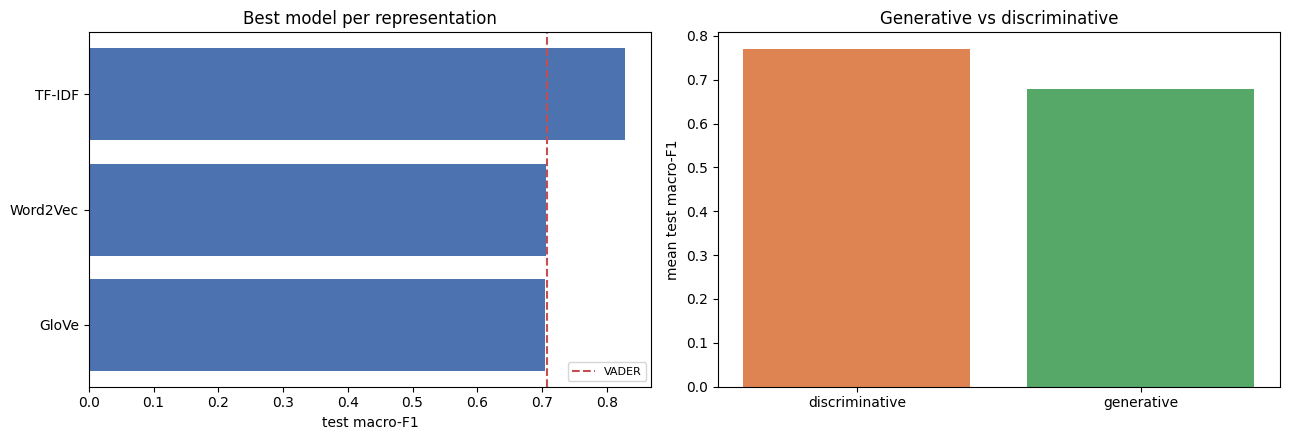

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

by_rep = master.groupby("representation")["macro_f1"].max().sort_values()
axes[0].barh(by_rep.index, by_rep.values, color="#4C72B0")
axes[0].axvline(baselines["vader"], color="#C44E52", ls="--", label="VADER")
axes[0].set_xlabel("test macro-F1")
axes[0].set_title("Best model per representation")
axes[0].legend(fontsize=8)

by_kind = master.groupby("kind")["macro_f1"].mean()
axes[1].bar(by_kind.index, by_kind.values, color=["#DD8452", "#55A868"])
axes[1].set_ylabel("mean test macro-F1")
axes[1].set_title("Generative vs discriminative")
plt.tight_layout()
plt.show()

## 3. Interactive prediction

Type a sentence, pick a model, see the prediction and the words that drove it.
**Red** pushes toward negative, **green** toward positive.

In [5]:
from lime.lime_text import LimeTextExplainer

explainer = LimeTextExplainer(class_names=LABELS, split_expression=tokenize,
                              random_state=42, bow=True)
NEG = LABELS.index("negative")


def highlight(text, model, num_features=8):
    """Render one sentence with per-word colouring from LIME weights."""
    probabilities = model.predict_proba([text])[0]
    prediction = model.predict([text])[0]

    explanation = explainer.explain_instance(
        text, model.predict_proba, num_features=num_features,
        num_samples=800, labels=[NEG])
    weights = dict(explanation.as_list(label=NEG))

    largest = max((abs(w) for w in weights.values()), default=1.0) or 1.0
    pieces = []
    for token in tokenize(text):
        weight = weights.get(token, 0.0)
        strength = min(abs(weight) / largest, 1.0) * 0.55
        colour = ("rgba(220,80,80,%.2f)" % strength if weight > 0
                  else "rgba(90,170,110,%.2f)" % strength)
        pieces.append(
            "<span style='background:%s;padding:2px 3px;border-radius:3px'>%s</span>"
            % (colour, token))

    bars = "".join(
        "<div style='margin:2px 0'><code>%-9s</code>"
        "<span style='display:inline-block;height:11px;width:%dpx;"
        "background:#4C72B0'></span> %.3f</div>" % (label, p * 260, p)
        for label, p in zip(LABELS, probabilities))

    body = (
        "<div style='font-family:system-ui;line-height:2.1;margin:8px 0'>"
        "<div style='font-size:15px'>%s</div>"
        "<p style='margin:10px 0 4px'><b>Prediction: %s</b></p>%s</div>"
        % (" ".join(pieces), prediction, bars))
    return HTML(body)

In [6]:
# Change this sentence and re-run the cell.
SENTENCE = "Kill the process before restarting the server."
MODEL = "tfidf13_svm"

display(highlight(SENTENCE, models[MODEL]))

### Widget version

A text box and a model dropdown, if `ipywidgets` is enabled.

In [7]:
try:
    import ipywidgets as widgets

    text_box = widgets.Textarea(
        value="Kill the process before restarting the server.",
        layout=widgets.Layout(width="680px", height="70px"))
    model_pick = widgets.Dropdown(options=available, value="tfidf13_svm",
                                  description="model:")
    button = widgets.Button(description="Predict", button_style="primary")
    output = widgets.Output()

    def on_click(_):
        with output:
            output.clear_output()
            display(highlight(text_box.value, models[model_pick.value]))

    button.on_click(on_click)
    display(widgets.VBox([text_box, widgets.HBox([model_pick, button]), output]))
    on_click(None)
except ImportError:
    print("ipywidgets not available - use the cell above instead.")

## 4. Example gallery

The first four sentences are technically harsh but functionally neutral. The last four
carry genuine sentiment.

In [8]:
GALLERY = [
    ("SE jargon, neutral", "Kill the process before restarting the server."),
    ("SE jargon, neutral", "The build failed with a fatal error on line 42."),
    ("SE jargon, neutral", "Garbage collection destroys unused objects automatically."),
    ("SE jargon, neutral", "A deadlock occurs when two threads wait on each other."),
    ("Genuine complaint", "The documentation is worthless and the maintainers ignore every issue."),
    ("Genuine complaint", "I regret choosing this library, it has been nothing but trouble."),
    ("Genuine praise", "Thanks, this works perfectly and saved me hours."),
    ("Neutral question", "How do I use this function with a custom comparator?"),
]

model = models["tfidf13_svm"]
rows = []
for kind, sentence in GALLERY:
    probabilities = model.predict_proba([sentence])[0]
    rows.append({"kind": kind, "sentence": sentence,
                 "predicted": model.predict([sentence])[0],
                 "P(neg)": round(probabilities[0], 3),
                 "P(neu)": round(probabilities[1], 3),
                 "P(pos)": round(probabilities[2], 3)})
display(pd.DataFrame(rows))

,kind,sentence,predicted,P(neg),P(neu),P(pos)
0,"SE jargon, neutral",Kill the process before restarting the server.,neutral,0.142,0.846,0.012
1,"SE jargon, neutral",The build failed with a fatal error on line 42.,negative,0.934,0.056,0.010
2,"SE jargon, neutral",Garbage collection destroys unused objects automatically.,neutral,0.118,0.864,0.018
3,"SE jargon, neutral",A deadlock occurs when two threads wait on each other.,neutral,0.293,0.690,0.017
4,Genuine complaint,The documentation is worthless and the maintainers ignore every issue.,neutral,0.262,0.707,0.031
5,Genuine complaint,"I regret choosing this library, it has been nothing but trouble.",negative,0.675,0.139,0.186
6,Genuine praise,"Thanks, this works perfectly and saved me hours.",positive,0.009,0.170,0.821
7,Neutral question,How do I use this function with a custom comparator?,neutral,0.038,0.917,0.045


## 5. The stress test - the project's central result

Senti4SD turned out to contain almost none of the harsh vocabulary this project is
about: `fatal` 0x, `hang` 0x, `abort` 0x, `kill` 3x in 3,031 posts. So the question is
answered on 60 hand-written sentences instead:

* **40 harsh-but-neutral** - technical vocabulary, no hostility
* **20 genuine complaints** - 10 with no jargon at all
* **10 minimal pairs** - the same jargon word, opposite intent

In [9]:
stress = pd.read_csv(RESULTS / "stress_test" / "stress_results_se.csv")
display(stress)

vader_rate = stress[stress["model"] == "vader"]["false_alarm_rate"].iloc[0]
anchor = stress[stress["model"] == "tfidf13_svm"].iloc[0]
print("VADER calls %.0f%% of harsh-but-neutral sentences negative."
      % (vader_rate * 100))
print("tfidf13_svm calls %.0f%%, while still catching %.0f%% of real complaints."
      % (anchor["false_alarm_rate"] * 100, anchor["negative_recall"] * 100))

,model,false_alarm_rate,negative_recall,recall_with_jargon,recall_without_jargon,minimal_pair_accuracy,accuracy
0,glove_gnb,0.025,0.70,0.9,0.5,0.9,0.8833
1,tfidf12_lr,0.050,0.50,0.7,0.3,0.6,0.8000
2,tfidf12_svm,0.050,0.45,0.7,0.2,0.6,0.7833
3,tfidf11_lr,0.075,0.65,0.7,0.6,0.6,0.8333
4,tfidf13_lr,0.075,0.65,0.7,0.6,0.6,0.8333
5,tfidf13_svm,0.075,0.75,0.8,0.7,0.7,0.8667
6,tfidf11_svm,0.100,0.65,0.7,0.6,0.6,0.8167
7,w2v_gnb,0.100,0.80,0.8,0.8,0.7,0.8667
8,tfidf11_mnb,0.225,0.60,0.6,0.6,0.4,0.7000
9,tfidf12_mnb,0.300,0.55,0.7,0.4,0.5,0.6500


VADER calls 70% of harsh-but-neutral sentences negative.
tfidf13_svm calls 8%, while still catching 75% of real complaints.


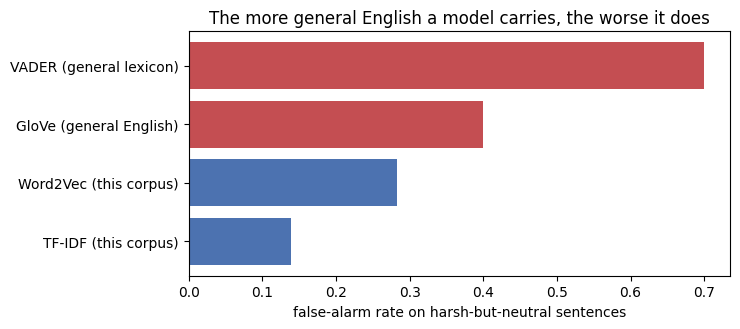

In [10]:
family = {"glove": "GloVe (general English)", "w2v": "Word2Vec (this corpus)"}
trained = stress[stress["model"] != "vader"].copy()
trained["family"] = trained["model"].map(
    lambda m: family.get(m.split("_")[0], "TF-IDF (this corpus)"))

means = trained.groupby("family")["false_alarm_rate"].mean()
means["VADER (general lexicon)"] = vader_rate
means = means.sort_values()

fig, ax = plt.subplots(figsize=(7.5, 3.4))
colours = ["#C44E52" if "general" in n else "#4C72B0" for n in means.index]
ax.barh(means.index, means.values, color=colours)
ax.set_xlabel("false-alarm rate on harsh-but-neutral sentences")
ax.set_title("The more general English a model carries, the worse it does")
plt.tight_layout()
plt.show()

**This answers Expected Outcome #3.** The false-alarm rate tracks how much general
English each representation carries: a general-purpose lexicon is worst, pretrained
GloVe inherits much of the bias, and vectors learned on StackOverflow largely avoid it.

In [11]:
display(HTML("<img src='../results/figures/stress_scatter_se.png' width='620'>"))

## 6. Why the model gets things wrong

Where the model reads a neutral post as hostile, LIME shows which words did it.

In [12]:
errors = pd.read_csv(RESULTS / "error_analysis" /
                     "neutral_as_negative_tfidf13_svm.csv")
print(str(len(errors)) + " neutral test posts predicted negative")
display(errors["tag"].value_counts().to_frame("count"))

for _, row in errors.head(2).iterrows():
    print("\n[" + row["tag"] + "]")
    display(highlight(" ".join(row["text"].split())[:220], model))

36 neutral test posts predicted negative


,count
tag,
other,17
mixed or contrastive,13
contains SE jargon,5
short question,1



[contains SE jargon]



[mixed or contrastive]


## 7. LIME and SHAP agree

Two different mathematical approaches on the same model and the same posts. Agreement
is evidence that both describe the model rather than their own sampling noise.

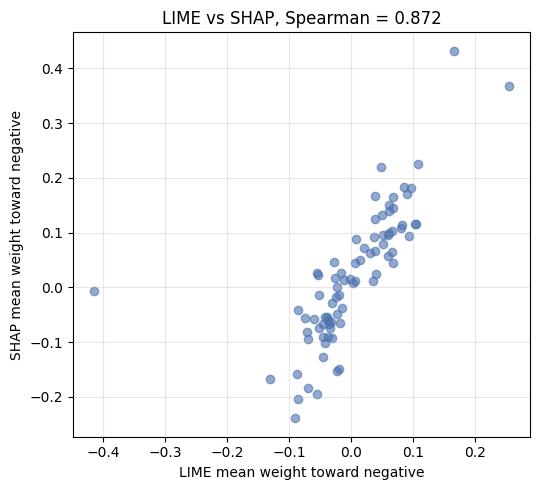

LIME stability across 5 seeds: mean Jaccard 0.907 (sd 0.164)


In [13]:
agreement = pd.read_csv(RESULTS / "explanations" / "lime_vs_shap_se.csv")
correlation = agreement["mean_weight_toward_negative_lime"].corr(
    agreement["mean_weight_toward_negative_shap"], method="spearman")

fig, ax = plt.subplots(figsize=(5.5, 5))
ax.scatter(agreement["mean_weight_toward_negative_lime"],
           agreement["mean_weight_toward_negative_shap"],
           alpha=0.6, color="#4C72B0")
ax.set_xlabel("LIME mean weight toward negative")
ax.set_ylabel("SHAP mean weight toward negative")
ax.set_title("LIME vs SHAP, Spearman = %.3f" % correlation)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

stability = pd.read_csv(RESULTS / "explanations" / "lime_stability_se.csv")
print("LIME stability across 5 seeds: mean Jaccard %.3f (sd %.3f)"
      % (stability["mean_jaccard"].iloc[0], stability["std_jaccard"].iloc[0]))

## 8. Summary

| Question | Answer |
|---|---|
| Best representation | **TF-IDF**, 0.8275 test macro-F1, ahead of Word2Vec (0.7059) and GloVe (0.7054) |
| Generative vs discriminative | Discriminative wins clearly: 0.7694 vs 0.6792 mean, McNemar p < 1e-8 |
| Domain cues or general-language bias? | The bias is real and measurable: VADER 70% false alarms, GloVe 40%, Word2Vec 28%, TF-IDF 14% |
| Working demo | This notebook |

**The most important caveat.** Senti4SD contains almost none of the harsh technical
vocabulary this project set out to study - four separate analyses confirmed it. The
central claim is therefore demonstrated on a hand-written stress set, written by one
person who already knew what the models were expected to get wrong. That is a real
limitation and it is stated plainly in the report.